# 02. Calibration Validation

This notebook loads the exported `calibration.json` and `scenarios.parquet` files to validate our simulation transition dynamics.

In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

with open('../data/processed/silverstone/calibration.json', 'r') as f:
    calib = json.load(f)

scenarios = pd.read_parquet('../data/processed/silverstone/scenarios.parquet')
print("Calibration fields:", list(calib.keys()))
print(f"Loaded {len(scenarios['race_id'].unique())} scenarios from scenarios.parquet")

# Color mapping for compounds as requested
tyre_colors = {
    "SOFT": "red",
    "MEDIUM": "yellow",
    "HARD": "black",
    "INTERMEDIATE": "green",
    "INTER": "green",
    "WET": "blue"
}

Calibration fields: ['circuit', 'total_laps', 'base_pace', 'pit_loss', 'noise_std', 'fuel', 'compounds', 'weather_compound_penalty', 'safety_car_probability_per_lap', 'safety_car_lap_time']
Loaded 3 scenarios from scenarios.parquet


## 1. Simulate and Compare Tyre Degradation Curves (Soft vs Medium vs Hard)

### Description & Representation
This plot simulates and compares the tire degradation penalty (in seconds) on the y-axis against the tire age (in laps) on the x-axis for the three dry compounds: SOFT (red), MEDIUM (yellow), and HARD (black).

### Technical Details
It uses the fitted coefficients (`base_deg`, `cliff_age`, `cliff_severity`) from `calibration.json` in the piecewise formula:
$$\text{deg}(t) = \text{base\_deg} \cdot t + \text{cliff\_severity} \cdot \max(0, t - \text{cliff\_age})^2$$
We vary $t$ from 1 to 45 to simulate stint progression.

### Strategic Insights
This plot illustrates the classic tire choice trade-offs in F1:
* **SOFT (Red)**: Wears out fast and hits a very early cliff ($\approx 27.2$ laps). It provides maximum pace but can only be run in short sprints.
* **MEDIUM (Yellow)**: Offers a balanced middle ground, hitting the cliff at $\approx 33.1$ laps.
* **HARD (Black)**: Highly durable. It has low base degradation and hits a late cliff ($32.0$ laps but with a flatter progression and lower severity), making it ideal for long race stints.

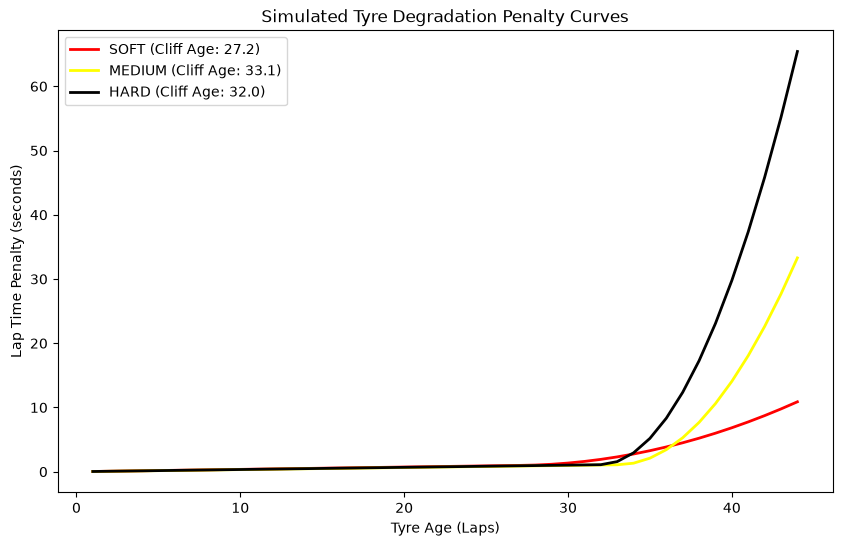

In [ ]:
def sim_tyre_deg(compound, age, params):
    comp_params = params["compounds"][compound]
    base_deg = comp_params["base_deg"]
    cliff_age = comp_params["cliff_age"]
    cliff_sev = comp_params["cliff_severity"]
    
    gradual = base_deg * age
    cliff = cliff_sev * np.maximum(0, age - cliff_age) ** 2
    return gradual + cliff

ages = np.arange(1, 45)
plt.figure(figsize=(10, 6))
for comp in ["SOFT", "MEDIUM", "HARD"]:
    deg_vals = [sim_tyre_deg(comp, age, calib) for age in ages]
    plt.plot(ages, deg_vals, label=f"{comp} (Cliff Age: {calib['compounds'][comp]['cliff_age']})", color=tyre_colors[comp], lw=2)

plt.title("Simulated Tyre Degradation Penalty Curves")
plt.xlabel("Tyre Age (Laps)")
plt.ylabel("Lap Time Penalty (seconds)")
plt.legend()
plt.show()

## 2. Simulate Single Stint Lap Times

### Description & Representation
This plot simulates the actual lap times (in seconds) on the y-axis against the lap number (and tire age) on the x-axis for a driver running a 42-lap stint on the `MEDIUM` compound (in yellow) from the start of a Grand Prix. A vertical red dashed line marks the tire's calibrated cliff age ($33.1$ laps).

### Technical Details
The plot merges two opposing physical effects to construct the stint profile:
1. **Linear Fuel Burn-off (Pace gets faster)**: As the car completes laps, it consumes fuel ($1.9\text{ kg/lap}$), reducing the weight and improving the pace by $0.033\text{ s/kg}$ per lap (net $\approx 0.063\text{ s/lap}$ pace improvement).
2. **Tire Wear (Pace gets slower)**: The tire ages and eventually crosses its cliff threshold, causing a quadratic pace penalty.
$$\text{LapTime}(t) = \text{BasePace} + \text{TyreDeg}(t) + (\text{LapsRemaining} \times 1.9 \times 0.033)$$

### Strategic Insights
This simulates the classic **F1 stint pace profile**:
* **Phase 1: Laps 1–25 (Fuel Dominant)**: Lap times steadily *decrease*. The car gets lighter as it burns fuel, which outweighs the gradual tire wear ($0.0326\text{ s/lap}$ pace loss).
* **Phase 2: Laps 26–33 (Balanced)**: Lap times flatten out as tire wear starts balancing out the fuel burn-off.
* **Phase 3: Laps 34–42 (Cliff Dominant)**: After crossing the `cliff_age` ($33.1$ laps), the quadratic tire degradation overrides the fuel burn-off, causing lap times to skyrocket. This visualizes why a strategist must pit: staying out past the cliff costs seconds per lap, quickly erasing any pit lane time loss.

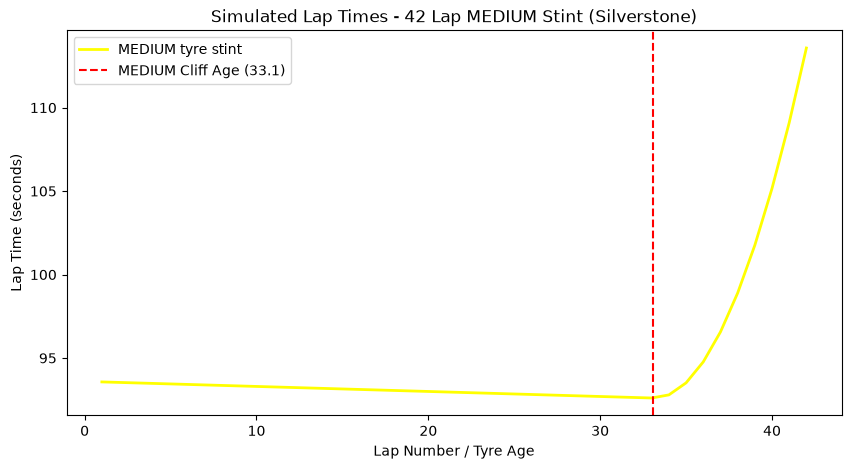

In [ ]:
base_pace = calib["base_pace"]
fuel_burn = calib["fuel"]["consumption_kg_per_lap"]
fuel_sens = calib["fuel"]["sensitivity_s_per_kg"]
total_laps = calib["total_laps"]

def sim_lap_time(compound, age, lap_number):
    deg = sim_tyre_deg(compound, age, calib)
    laps_remaining = total_laps - lap_number
    fuel_kg = laps_remaining * fuel_burn
    fuel_eff = fuel_kg * fuel_sens
    return base_pace + deg + fuel_eff

# Simulate running 42 laps on MEDIUM from the start of the race to clearly cross the cliff_age (33.1)
lap_numbers = np.arange(1, 43)
sim_times = [sim_lap_time("MEDIUM", age, age) for age in lap_numbers]

plt.figure(figsize=(10, 5))
plt.plot(lap_numbers, sim_times, label="MEDIUM tyre stint", color="yellow", lw=2)
plt.axvline(calib["compounds"]["MEDIUM"]["cliff_age"], color="red", linestyle="--", label=f"MEDIUM Cliff Age ({calib['compounds']['MEDIUM']['cliff_age']})")
plt.title("Simulated Lap Times - 42 Lap MEDIUM Stint (Silverstone)")
plt.xlabel("Lap Number / Tyre Age")
plt.ylabel("Lap Time (seconds)")
plt.legend()
plt.show()